<a href="https://colab.research.google.com/github/AyushiB56/Neural-Network/blob/main/MNIST_Dataset_with_pytorch(rnn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms


In [2]:
X_train= torchvision.datasets.MNIST(root='./data', train=True, download=True,transform=transforms.ToTensor())
X_test= torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 129MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 32.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 74.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.97MB/s]


In [5]:
import matplotlib.pyplot as plt

In [7]:
X_train

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [28]:
X_train[8000]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

Building on the previous explanation, X_train[8000][0][0] goes one level deeper into the structure of the data. Let's break it down again:

X_train[8000]: This accesses the 8001st sample from the X_train dataset. This returns a tuple containing the image tensor and the label.

Tuple: (image_tensor, label)
X_train[8000][0]: This accesses the first element of the tuple returned in the previous step, which is the image tensor.

Image Tensor: This is a PyTorch tensor representing the image. For MNIST, the image tensor typically has a shape like (C, H, W) where C is the number of channels (1 for grayscale), H is the height, and W is the width (28x28 for MNIST).
X_train[8000][0][0]: This accesses the first element of the image tensor obtained in the previous step. Since the image tensor for MNIST has a shape like (1, 28, 28), the first index [0] accesses the first channel of the image.

Therefore, X_train[8000][0][0] retrieves the entire first channel of the image tensor for the 8001st sample. For a single-channel grayscale image like MNIST, this effectively gives you the image tensor itself, but potentially with the channel dimension removed if you were to access multiple channels later.

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
print(image.size)


<built-in method size of Tensor object at 0x7c6f3cd3e510>


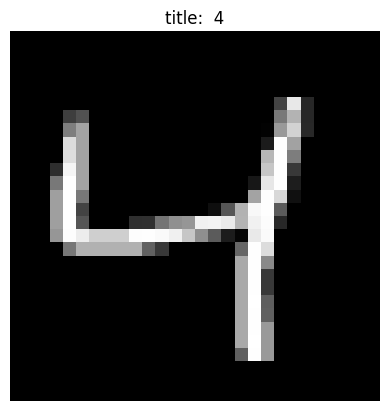

In [ ]:

plt.imshow(image.squeeze(), cmap= 'gray')
plt.title(f'title:  {label}')
plt.axis('off')
plt.show()

loading is complete

DATA LOADER


In [29]:
from torch.utils.data import DataLoader

In [87]:
train_loader= DataLoader(X_train, shuffle= True, batch_size=32, drop_last = True)
test_loader= DataLoader(X_test, shuffle= False, batch_size=32, drop_last = True)

In [94]:
for x, y in train_loader:
  print(x)
  print(y)
  break

tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]],


        ...,


        [[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0.

In [95]:
len(train_loader)

1875

In [96]:
ho[0][0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [97]:
class Rnn_module(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_of_layers):
    super(Rnn_module,self).__init__()
    self.hidden_size= hidden_size
    self.num_layers= num_of_layers
    self.rnn= nn.RNN(input_size, hidden_size, num_of_layers, batch_first=True)
    self.fc= nn.Linear(hidden_size, output_size)


  def forward(self,x):
    ho= torch.zeros(self.num_layers,x.size(0),self.hidden_size )
    out,_ = self.rnn(x, ho)

    final_state= out[:,-1,:]
    final_output= self.fc(final_state)
    return final_output



In [110]:
def train():

  num_of_steps= len(train_loader)
  rnn_model= Rnn_module(input_size=28, hidden_size=128, output_size=10, num_of_layers= 2)
  loss= nn.CrossEntropyLoss()
  optimizer= torch.optim.Adam(rnn_model.parameters(), lr=0.005)
  loss_epoch=[]
  for epochs in range(10000):
    current_loss=0
    for image, labels in train_loader:
      image=image.reshape(-1, 28, 28)
      output= rnn_model(image)
      Loss_fn= loss(output, labels)
      optimizer.zero_grad()
      Loss_fn.backward()
      optimizer.step()

      current_loss+= Loss_fn.item()
    loss_epoch.append(current_loss/num_of_steps)
  return Loss_epoch




In [111]:
def predict():
  num_samples=0
  no_of_correct=0
  with torch.no_grad():
    for x,y in test_loader:
      x= x.reshape(-1,sequence_length,input_size)
      output= rnn_model(x)
      _, predicted = torch.max(outputs.data, 1)

      if predicted==y:
        no_of_correct+=1
      num_samples+=1

  print("accuracy : ",  (no_of_correct/num_samples)*100)




In [ ]:
train()

In [ ]:
predict()